# 1. Libraries

In [1]:
# === Core Python Utilities ===
import os
import re
import math
import random
import warnings
from datetime import datetime
from itertools import combinations
from collections import Counter
from typing import List, Tuple, Dict, Optional

# === Scientific Computing ===
import numpy as np
import pandas as pd
import scipy
from scipy.stats import skew

# === Visualization ===
import matplotlib.pyplot as plt
import seaborn as sns
import missingno
import mplcursors
from matplotlib.colors import LinearSegmentedColormap

# === Progress & Optimization ===
from tqdm.notebook import tqdm
tqdm.pandas()
import optuna

# === Data Preprocessing ===
from sklearn.preprocessing import (
    StandardScaler, MinMaxScaler, PowerTransformer,
    OneHotEncoder, LabelEncoder, OrdinalEncoder
)
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectFromModel
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.manifold import TSNE


# === Train/Test Splits & Cross-Validation ===
from sklearn.model_selection import (
    train_test_split, KFold, StratifiedKFold,
    cross_val_predict, cross_val_score,
    GridSearchCV, RandomizedSearchCV, ParameterGrid
)

# === Metrics & Evaluation ===
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, auc, roc_curve,
    classification_report, confusion_matrix,
    precision_recall_curve, make_scorer
)

from sklearn.decomposition import PCA
# === Pipelines ===
from sklearn.pipeline import make_pipeline

# === Machine Learning Models ===
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.neural_network import MLPClassifier

from xgboost import XGBClassifier
import xgboost as xgb

from lightgbm import LGBMClassifier
import lightgbm as lgb
from catboost import CatBoostClassifier

# from catboost import CatBoostClassifier, CatBoostRegressor, Pool, cv
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
import optuna

In [2]:
from training_module import (
    evaluate_model,                     # Hàm thực hiện đánh giá mô hình trên tập dev và test
    optimize_threshold_by_f1           # Hàm thực hiện tối ưu hoá ngưỡng phân loại
)

In [3]:
# Một số setting cơ bản
import warnings
import pandas as pd
warnings.filterwarnings ('ignore')
pd.set_option ('display.width', None)
pd.set_option ('display.max_rows', 100)
pd.set_option ('display.max_columns', 50)

# 2. Data

In [4]:
file_path = '/Users/kittnguyen/Documents/us-flight-project/data/silver_data/'
X_train = np.load(f"{file_path}train/X_train.npy", allow_pickle=True)
y_train = np.load(f"{file_path}train/y_train.npy", allow_pickle=True)
X_dev = np.load(f"{file_path}dev/X_dev.npy", allow_pickle=True)
y_dev = np.load(f"{file_path}dev/y_dev.npy", allow_pickle=True)
X_test = np.load(f"{file_path}test/X_test.npy", allow_pickle=True)
y_test = np.load(f"{file_path}test/y_test.npy", allow_pickle=True)

# 3. Logistic Regression

## a. From Scratch

In [ ]:
class LogisticRegression2:
    def __init__(self, epoch: int = 10, lr: float = 0.01, batch_size: int = 10000, 
                 early_stopping: bool = False, patience: int = 3, tol: float = 1e-4):
        """
        Logistic Regression sử dụng Mini-Batch Gradient Descent với Early Stopping
            + epoch: số lần duyệt toàn bộ dataset
            + lr: learning rate
            + batch_size: kích thước mỗi batch
            + early_stopping: bật/tắt cơ chế dừng sớm
            + patience: số epoch chờ trước khi dừng nếu không cải thiện
            + tol: ngưỡng cải thiện tối thiểu để reset patience
        """
        self.epoch = epoch
        self.lr = lr
        self.batch_size = batch_size
        self.losses = []
        self.metrics = []
        
        self.early_stopping = early_stopping
        self.patience = patience
        self.tol = tol
        
    def sigmoid (self, z : np.ndarray) -> np.ndarray:
        """Hàm sigmoid ổn định số học"""
        z = np.clip(z, -500, 500)
        return 1 / (1 + np.exp(-z))
    
    def _gradient(self, X: np.ndarray, y: np.ndarray) -> np.ndarray:
        """Tính gradient cho 1 batch"""
        y_hat = self.predict(X)
        diff = y_hat - y
        return (X.T @ diff) / len(y)
    
    # def accuracy (self, y : np.ndarray, y_hat : np.ndarray) -> float:
    #     ''''''
    #     return (1 - np.abs (y - y_hat)).mean ()
    
    def accuracy(self, y: np.ndarray, y_hat: np.ndarray) -> float:
        ''' Tính accuracy theo cách chuẩn '''
        y_pred = (y_hat >= 0.5).astype(int)  # Chuyển xác suất thành 0 hoặc 1
        return (y == y_pred).mean()  # Tính tỷ lệ dự đoán đúng

    
    def logloss (self, y : np.ndarray, y_hat : np.ndarray) -> float:
        '''
        matmul đối với 2 mảng 1 chiều --> Tích vô hướng, trả về 1 số
        * đối với 2 mảng 1 chiều --> Nhân từng phần tử
        => Phải tính tổng của cả mảng sau khi đã *, rồi chia cho m => mean ()
        '''
        
        # m = len (y)
        # costfunction = np.matmul (y, np.log (y_hat)) + np.matmul (1-y,np.log (1-y_hat))
        # return -1/m * costfunction
    
        costfunction = y * np.log(y_hat+1e-16) + (1 - y) * np.log(1 - y_hat+1e-16)
        return -np.mean(costfunction)
 
    def fit(self, X: np.ndarray, y: np.ndarray):
        X = X.astype(np.float32)
        y = y.reshape(-1, 1).astype(np.float32)
        n, d = X.shape
        self.theta = np.zeros((d, 1), dtype=np.float32)

        best_loss = np.inf
        epochs_no_improve = 0
        best_theta = None

        with tqdm(range(self.epoch)) as pb:
            for e in pb:
                indices = np.random.permutation(n)
                X, y = X[indices], y[indices]

                for start in range(0, n, self.batch_size):
                    end = start + self.batch_size
                    X_batch = X[start:end]
                    y_batch = y[start:end]
                    grad = self._gradient(X_batch, y_batch)
                    self.theta -= self.lr * grad

                y_hat_all = self.predict_proba(X)
                loss = self.logloss(y, y_hat_all)
                acc = self.accuracy(y, y_hat_all)

                self.losses.append(loss)
                self.metrics.append(acc)

                pb.set_postfix({"loss": f"{loss:.4f}", "acc": f"{acc:.4f}"})

                if self.early_stopping:
                    if best_loss - loss > self.tol:
                        best_loss = loss
                        epochs_no_improve = 0
                        best_theta = self.theta.copy()
                    else:
                        epochs_no_improve += 1

                    if epochs_no_improve >= self.patience:
                        print(f"\nEarly stopping at epoch {e+1}")
                        if best_theta is not None:
                            self.theta = best_theta
                        break

    def predict_proba(self, X: np.ndarray) -> np.ndarray:
        """Dự đoán xác suất (giống sklearn.predict_proba[:,1])"""
        z = np.dot(X, self.theta)
        return self.sigmoid(z)
        
    def predict (self, X : np.ndarray) -> float:
        ''''''
        proba = self.predict_proba(X)
        return (proba >= 0.5).astype(int)

In [7]:
logistic_model = LogisticRegression2(epoch=1000, lr=0.001, batch_size=10000)
logistic_model.fit (X_train, y_train)

  0%|          | 0/1000 [00:00<?, ?it/s]

### Dev

Evaluation on  set:
Accuracy : 0.5785
Precision: 0.4059
Recall   : 0.2422
F1-score : 0.3034
ROC AUC  : 0.5362


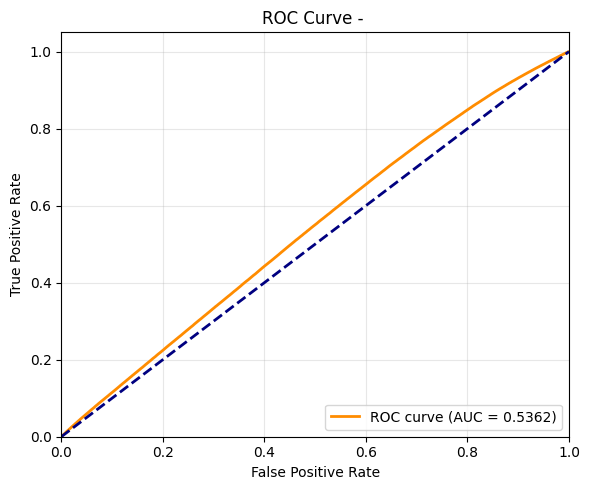

Classification Report:
              precision    recall  f1-score   support

           0       0.63      0.78      0.70    837529
           1       0.41      0.24      0.30    511152

    accuracy                           0.58   1348681
   macro avg       0.52      0.51      0.50   1348681
weighted avg       0.54      0.58      0.55   1348681



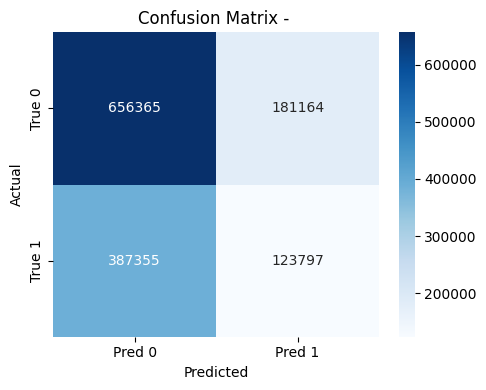

In [9]:
# --- Predicting ---
y_pred_dev = logistic_model.predict(X_dev)
y_proba_dev = logistic_model.predict_proba(X_dev) # Probability

# --- Evaluating ---
evaluate_model (y_dev, y_pred_dev, y_proba_dev)

### Test

Evaluation on  set:
Accuracy : 0.578
Precision: 0.4051
Recall   : 0.242
F1-score : 0.303
ROC AUC  : 0.5356


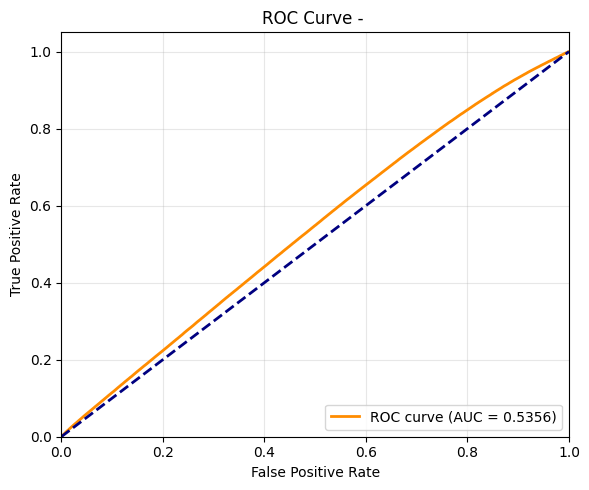

Classification Report:
              precision    recall  f1-score   support

           0       0.63      0.78      0.70    837529
           1       0.41      0.24      0.30    511152

    accuracy                           0.58   1348681
   macro avg       0.52      0.51      0.50   1348681
weighted avg       0.54      0.58      0.55   1348681



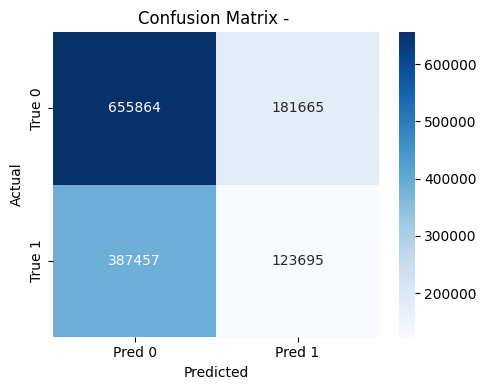

In [10]:
# --- Predicting ---
y_pred_test = logistic_model.predict(X_test)
y_proba_test = logistic_model.predict_proba(X_test) # Probability

# --- Evaluating ---
evaluate_model (y_test, y_pred_test, y_proba_test)

## b. From scikit-learn

### Training

In [12]:
# --- Logistic Regression --- 
logistic_model2 = LogisticRegression(
    penalty='l2',
    C=0.1,
    solver='liblinear',
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)
# --- Training ---
logistic_model2.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,0.1
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'liblinear'
,max_iter,1000
,multi_class,'deprecated'


### Predicting & Evaluating

#### Dev

Evaluation on  set:
Accuracy : 0.6316
Precision: 0.511
Recall   : 0.6477
F1-score : 0.5713
ROC AUC  : 0.6840


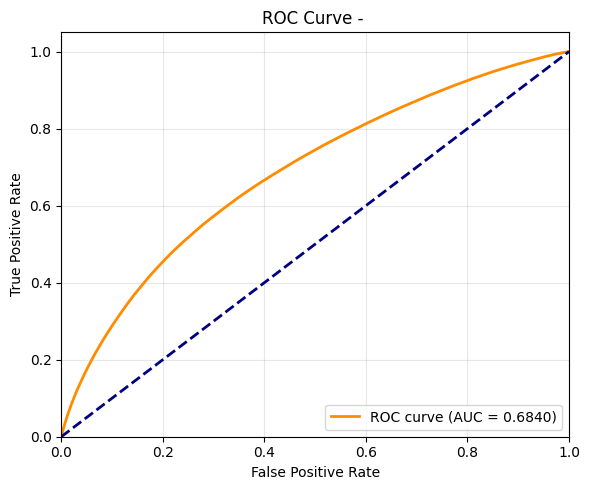

Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.62      0.68    837529
           1       0.51      0.65      0.57    511152

    accuracy                           0.63   1348681
   macro avg       0.63      0.63      0.62   1348681
weighted avg       0.66      0.63      0.64   1348681



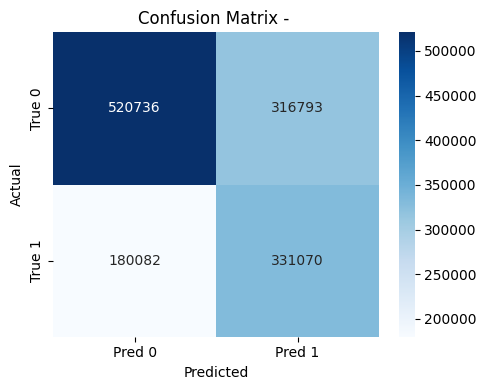

Best threshold: 0.50 with F1-score: 1.0000


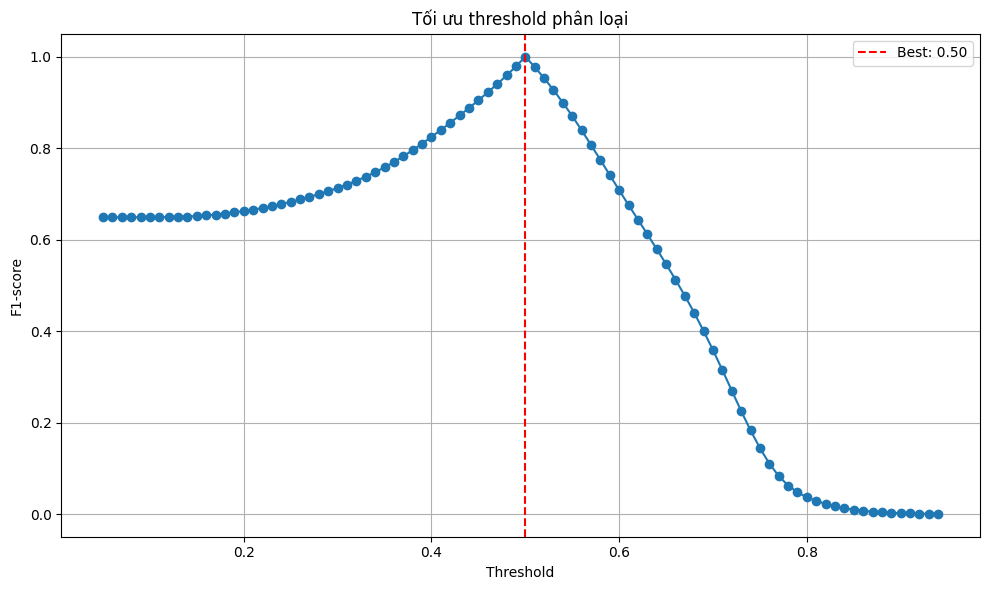

(np.float64(0.5000000000000001), 1.0)

In [13]:
# --- Predicting ---
y_pred_dev = logistic_model2.predict(X_dev)
y_proba_dev = logistic_model2.predict_proba(X_dev)[:, 1] # Probability

# --- Evaluating ---
evaluate_model (y_dev, y_pred_dev, y_proba_dev)

# --- Optimizing ---
optimize_threshold_by_f1 (logistic_model2, X_dev, y_pred_dev)

#### Test

Evaluation on  set:
Accuracy : 0.6322
Precision: 0.5116
Recall   : 0.6484
F1-score : 0.5719
ROC AUC  : 0.6840


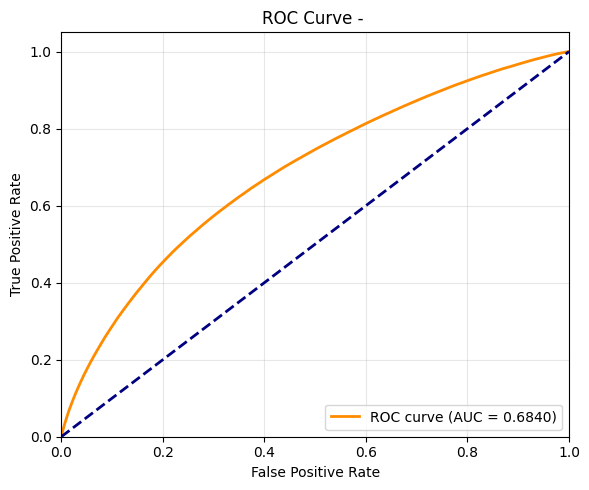

Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.62      0.68    837529
           1       0.51      0.65      0.57    511152

    accuracy                           0.63   1348681
   macro avg       0.63      0.64      0.62   1348681
weighted avg       0.66      0.63      0.64   1348681



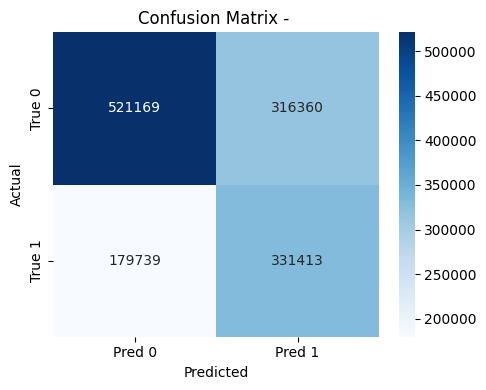

Best threshold: 0.50 with F1-score: 1.0000


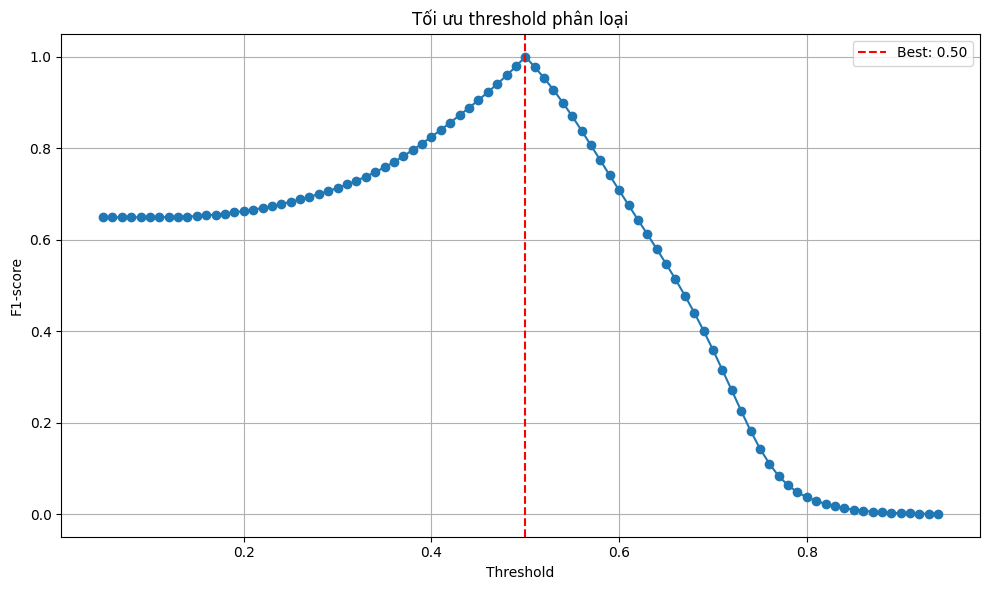

(np.float64(0.5000000000000001), 1.0)

In [14]:
# --- Predicting ---
y_pred_test = logistic_model2.predict(X_test)
y_proba_test = logistic_model2.predict_proba(X_test)[:, 1] # Probability

# --- Evaluating ---
evaluate_model (y_test, y_pred_test, y_proba_test)

# --- Optimizing ---
optimize_threshold_by_f1 (logistic_model2, X_test, y_pred_test)

In [15]:
print("Coefficients (weights) của các đặc trưng:")
print(logistic_model2.coef_)

# In intercept (bias)
print("Intercept:")
print(logistic_model2.intercept_)

Coefficients (weights) của các đặc trưng:
[[ 0.12797534  0.01605018  0.03719361  0.14124907  0.0267608   0.01159458
   0.02667345 -0.04421073  0.0968135   0.07917009  0.02421244  0.01230027
   0.01036078 -0.01700145  0.03876807  0.03075201  0.04065762  0.04035848
  -0.10905036  0.06663749 -0.13880742 -0.1394622  -0.16498316  0.07613169
  -0.32731387 -0.43714227  0.15521629  0.99696588  0.13483515 -0.28083762
  -0.66517187 -0.14528519  0.64701328  0.20303049 -0.12257081  0.37541083
   0.53943226 -0.34982982 -0.77339491 -0.4669231   0.07812061  0.18042084
   0.27576441  0.05731011 -0.20442978  0.06570337 -0.40272975 -0.4684244
  -0.11749568  0.18319033 -0.45804084 -0.24926597 -0.13817464 -0.26359001
   0.34123568  0.31099947  0.48204084  0.03210558 -0.28758033 -0.22058726
  -0.35699725 -0.21295681  0.02476574 -0.12707779 -0.0052936   1.46149172
  -0.20442978  0.06570337]]
Intercept:
[-0.20838164]
